In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "../data/processed/reddit_posts_cleaned.csv"
)

text = (
    df["keyword"].fillna("")
    + " "
    + df["clean_title"].fillna("")
)

In [3]:
vectorizer = CountVectorizer(

    stop_words="english",

    max_features=1000

)

X = vectorizer.fit_transform(text)

lda = LatentDirichletAllocation(

    n_components=5,

    random_state=42

)

topics = lda.fit_transform(X)

df["topic"] = topics.argmax(axis=1)

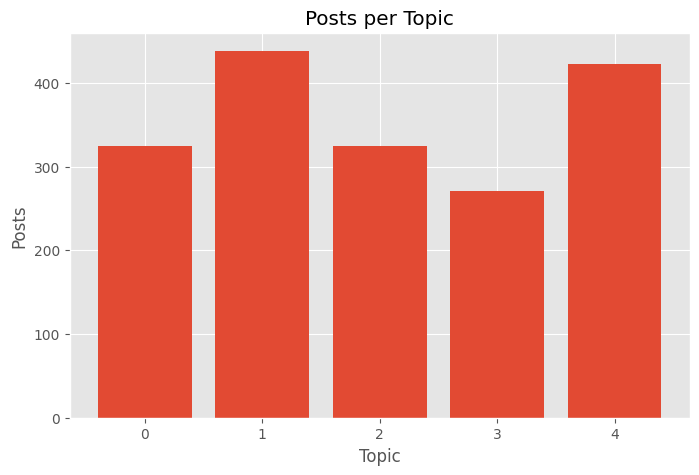

In [4]:
counts = df["topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(

    counts.index.astype(str),

    counts.values

)

plt.title("Posts per Topic")

plt.xlabel("Topic")

plt.ylabel("Posts")

plt.show()

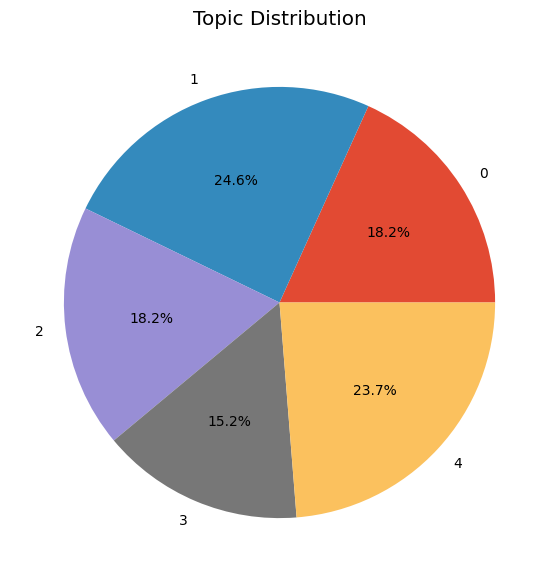

In [5]:
plt.figure(figsize=(7,7))

plt.pie(

    counts,

    labels=counts.index,

    autopct="%1.1f%%"

)

plt.title("Topic Distribution")

plt.show()

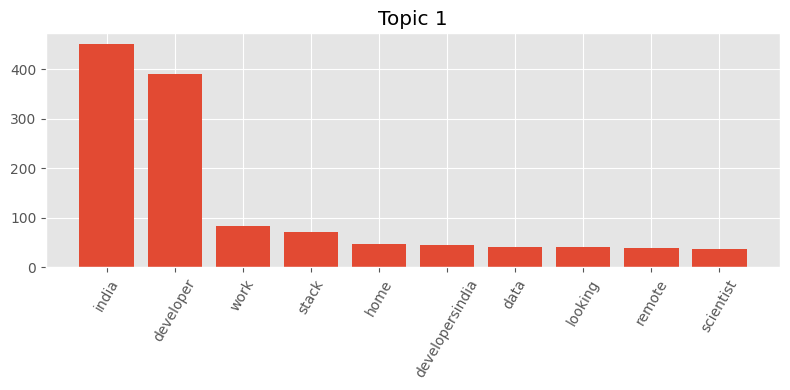

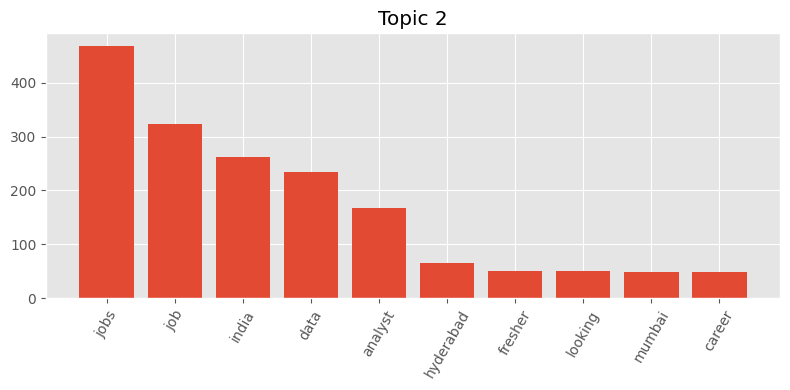

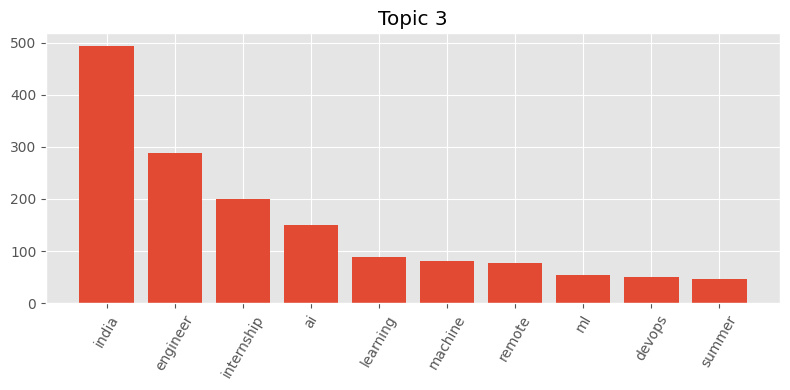

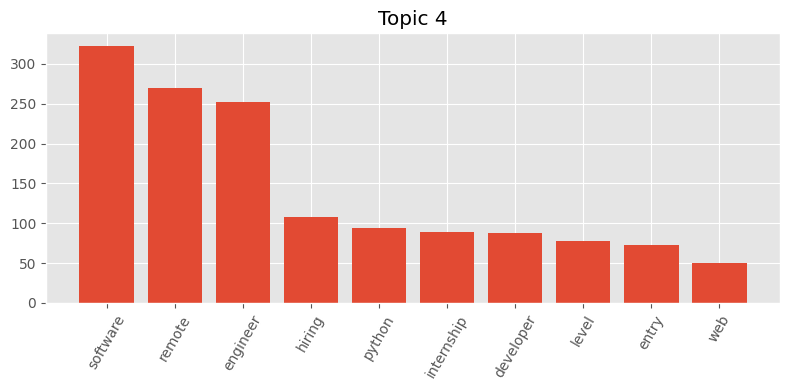

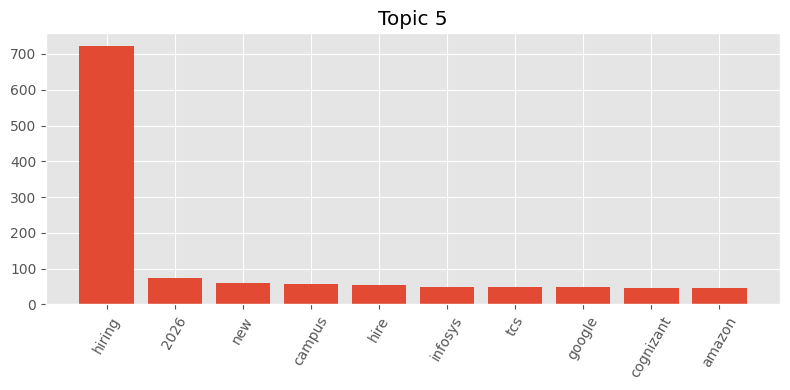

In [6]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):

    top = topic.argsort()[-10:][::-1]

    plt.figure(figsize=(8,4))

    plt.bar(

        [words[j] for j in top],

        topic[top]

    )

    plt.xticks(rotation=60)

    plt.title(f"Topic {i+1}")

    plt.tight_layout()

    plt.show()

In [7]:
for topic in sorted(df["topic"].unique()):

    print("=" * 80)

    print(f"Topic {topic}")

    print(df[df["topic"] == topic]["title"].head(5).to_string(index=False))

Topic 0
    Who's hiring? - Monthly Megathread - June 2026
Who's hiring? - Monthly Megathread - February 2026
Who's looking for work? - Monthly Megathread - ...
     Who's hiring? - Monthly Megathread - May 2026
Who's looking for work? - Monthly Megathread - ...
Topic 1
What strategy helped you in your job search (mo...
Bengaluru software engineer loses whopping Rs 1...
                Switch from Non IT to Data Analyst
1 year experience as Data Analyst, job hunting ...
Is Data Analyst really worth it for freshers in...
Topic 2
[0 YoE, Unemployed, Software Engineer / AI Engi...
JPMC (23 LPA, 5 days WFO) vs Bread Financial (2...
Is their anyone Who's working on full-time remo...
AI Training Side Hustle in India: Earn $16–$27/...
[Hiring] AI Engineer (Junior/Fresher) – Interns...
Topic 3
Joined Microsoft as a Senior Software Engineer ...
I am qutting software engineering, 5YOE in my m...
       Meta - Software Engineer | Offer Received 🎉
   From a farmer’s daughter to a software engineer